# Wprowadzenie do Geopandas – Twój pierwszy krok w świat map!
---

Witaj na kolejnych zajęciach! Rozpoczynamy dzisiaj zupełnie nową, fascynującą przygodę – wkraczamy w świat danych przestrzennych i geolokalizacyjnych (GIS).

Do tej pory pracowaliśmy na standardowych tabelach dwuwymiarowych, gdzie komórki zawierały teksty lub liczby. Dzisiaj poznamy potężny pakiet **Geopandas**. Możesz o nim myśleć jak o *"Pandasie na sterydach"* zaprojektowanym specjalnie dla kartografów i analityków.

Geopandas pod maską korzysta ze wszystkich funkcji klasycznego `pandas`, które już doskonale znasz (np. ładowanie plików, grupowanie, złączenia `merge`, filtrowanie po kolumnach), ale wznosi to na zupełnie nowy poziom. Wprowadza on **nowy typ struktury danych zwany `GeoDataFrame`**. Czym się różni od zwykłego DataFrame? Posiada zawsze jedną, obowiązkową i wyjątkową kolumnę, która tradycyjnie nosi nazwę **`geometry`**.

To w kolumnie `geometry` dzieje się prawdziwa magia. Zamiast zwykłych liter, przechowuje ona skomplikowane obiekty topologiczne:
* **Punkty (Point)** – np. konkretne współrzędne miasta, restauracji, bankomatu.
* **Linie (LineString)** – np. bieg rzek, wyznaczone szlaki drogowe, trasy samolotów.
* **Wielokąty (Polygon / MultiPolygon)** – np. zarysy kontynentów, państw, kształty województw, czy nawet zarys konkretnej działki z lotu ptaka.

Dzięki temu, że Pandas "wie", co znajduje się w kolumnie `geometry`, zyskuje supermoce. Pozwala to, używając dosłownie jednej linijki kodu `.plot()`, narysować skomplikowaną mapę świata!

**Podczas tych zajęć nauczymy się m.in.:**
* Wczytywania danych przestrzennych z popularnych formatów geolokalizacyjnych, takich jak **GeoJSON**, bezpośrednio z internetu.
* Łączenia map ze standardowymi danymi z GUS (operacje `merge`).
* Tworzenia **kartogramów** (tzw. choropleth maps), czyli automatycznego kolorowania obszarów na mapie (np. województw) gradientem od bieli do intensywnej czerwieni, bazując wyłącznie na wartości z przypisanej zmiennej liczbowej (np. wielkości populacji).
* Oraz analizy punktowej: zamiany surowych współrzędnych X i Y na przestrzenne obiekty typu `POINT`, nanoszenia ich na gotową mapę Polski, a także automatycznego wyliczania matematycznych środków wielokątów (tzw. **Centroidów**) w celu tworzenia idealnych etykiet.
---

## Zadanie 1: Wczytywanie danych, pierwsza mapa i zasady Estetyki
---

Zanim przejdziemy do polskich danych, narysujmy całą mapę świata. Pobierzemy w tym celu darmowy plik w popularnym dla map formacie **GeoJSON** z repozytorium GitHub.

Od razu zastosujemy na niej zasady *Declutteringu* (usuwania szumu), które poznaliśmy na poprzednich zajęciach. Biblioteka rysująca domyślnie dodaje na mapach ramki i osie z długością i szerokością geograficzną. My pozbędziemy się ich, by mapa wyglądała czysto i profesjonalnie.

---
**Szczegółowe wyjaśnienie funkcji, których użyjesz:**
* `gpd.read_file(url)` – kluczowa funkcja! Działa jak `pd.read_csv()`, ale konwertuje współrzędne z pliku do kształtów wielokątów, tworząc obiekt `GeoDataFrame`.
* `fig, ax = plt.subplots(figsize=(szerokość, wysokość))` – z biblioteki `matplotlib`. Przygotowuje dla nas puste "płótno" (`fig`) oraz osie (`ax`), na których będziemy malować naszą mapę.
* `.plot(ax=ax)` – wywołując tę metodę na tabeli przestrzennej, przekazujemy jej nasze płótno `ax=ax`. Geopandas automatycznie odszuka kolumnę o nazwie `geometry` i narysuje kształty.
* **Argumenty estetyczne w funkcji `.plot()`:**
    * `color='kolor'` – kolor wypełnienia konturów państw (np. `'lightgrey'`).
    * `edgecolor='kolor'` – kolor linii brzegowych (granic), np. `'dimgrey'`.
* **Czyszczenie wykresu:**
    * `ax.set_axis_off()` – ta genialna metoda jednym poleceniem ukrywa całą ramkę (spines) wokół mapy oraz liczby na osiach X i Y.
    * `ax.set_title("Tytuł", fontsize=..., fontweight='bold')` – dodaje główny tytuł wykresu na samej górze.
---
**Instrukcja krok po kroku:**
1. Zaimportuj wymagane pakiety: `import geopandas as gpd` oraz `import matplotlib.pyplot as plt`.
2. Przypisz poniższy tekstowy link do zmiennej `url_swiat`:
   `"https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"`
3. Wczytaj dane z linku używając `gpd.read_file(url_swiat)` i zapisz wynik do zmiennej `df_swiat`.
4. Stwórz czyste płótno o rozmiarze 15 na 8 cali: `fig, ax = plt.subplots(figsize=(15, 8))`.
5. Wywołaj metodę `.plot()` na zmiennej `df_swiat`. Wewnątrz nawiasów podaj: `ax=ax`, `color='whitesmoke'` oraz `edgecolor='gray'`.
6. Pozbądź się osi i liczb na brzegach za pomocą funkcji `ax.set_axis_off()`.
7. Dodaj tytuł używając `ax.set_title("Mapa Świata - estetyczny widok", fontsize=20, fontweight='bold')`.
8. Na końcu wywołaj `plt.show()`, aby wyczyścić pamięć i wygenerować obrazek.
---

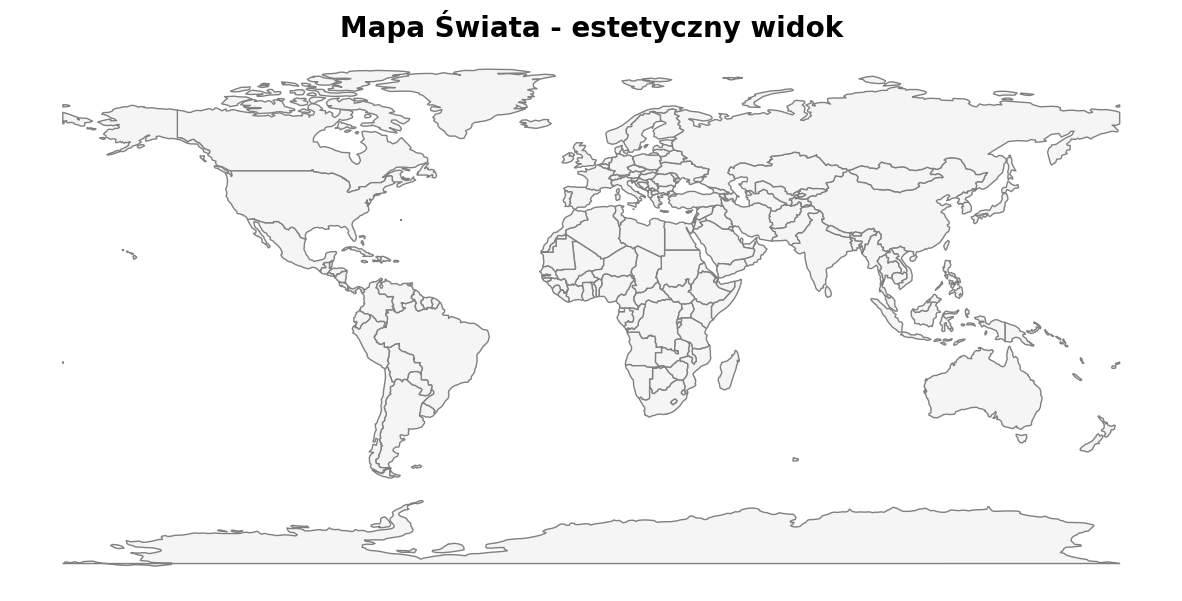

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
url_swiat = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
fig, ax = plt.subplots(figsize=(15, 8))
df_swiat = gpd.read_file(url_swiat)
df_swiat.plot(ax=ax, color = 'whitesmoke', edgecolor = 'gray')
ax.set_axis_off()
ax.set_title("Mapa Świata - estetyczny widok", fontsize=20, fontweight='bold')
plt.show()

---
## Zadanie 2: Kartogram – od bieli do czerwieni (Populacja Polski)
---

W tym zadaniu stworzymy **kartogram** (ang. *choropleth map*). Jest to mapa, na której obszary (np. województwa) są pokolorowane w zależności od wartości zmiennej statystycznej – w naszym przypadku będzie to **populacja z 2023 r.**

Aby to zrobić, musimy dokonać **połączenia (merge)** dwóch tabel. Kształty województw znajdują się w pliku z internetu (Geopandas), a liczby dotyczące ludności stworzymy w zwykłym słowniku (Pandas).

---
**Ważne pojęcia i argumenty w tym zadaniu:**
* **Zgodność kluczy:** W pliku z GitHuba nazwy w kolumnie `'name'` to np. `"Świętokrzyskie"`, `"Mazowieckie"` (duża litera, bez słowa województwo). Nasze dane statystyczne w Pandas muszą wyglądać *identycznie*, inaczej tabele się nie połączą!
* `df_lewa.merge(df_prawa, left_on='nazwa_kol_1', right_on='nazwa_kol_2')` – łączy mapę z liczbami. Szuka dopasowań w lewej tabeli po kolumnie ze zdefiniowanego `left_on`, a w prawej z `right_on`.
* **Argumenty do tworzenia Kartogramu w funkcji `.plot()`:**
   * `column='nazwa_kolumny'` – podstawa! Mówi pakietowi: *"Weź liczby z tej kolumny i dopasuj intensywność koloru na mapie do wielkości tych liczb."*
   * `cmap='Reds'` – z ang. *Colormap* (paleta kolorów). `'Reds'` sprawi, że mapa będzie pokolorowana płynnym gradientem: **od całkowitej bieli dla najmniejszej populacji, do intensywnej czerwieni dla największej**.
   * `legend=True` – wyświetla z boku pasek z podziałką, tłumaczący jakie odcienie czerwieni odpowiadają ilu tysiącom ludności.
---
**Instrukcja krok po kroku:**
1. Importuj moduł Pandas: `import pandas as pd`.
2. Przypisz link do zmiennej `url_pl`: `"https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/poland.geojson"` i wczytaj do zmiennej `df_polska` za pomocą `gpd.read_file()`.
3. W kodzie poniżej przygotowałem dla Ciebie poprawnie sformatowany słownik `dane_gus`. Użyj `pd.DataFrame(dane_gus)`, aby stworzyć z niego tabelę i nazwij ją `df_populacja`.
4. Połącz dane za pomocą metody `df_polska.merge()`. Użyj `df_populacja` jako prawej tabeli. Połącz na kluczach: `left_on='name'` oraz `right_on='wojewodztwo'`. Wynik zapisz do zmiennej `df_mapa_pop`.
5. Zainicjuj czyste płótno: `fig, ax = plt.subplots(figsize=(10, 10))`.
6. Narysuj kartogram! Na połączonej tabeli `df_mapa_pop` wywołaj `.plot(...)`. Pomiędzy nawiasami podaj parametry:
   * `ax=ax`
   * `column='populacja'`
   * `cmap='Reds'`
   * `edgecolor='black'`
   * `legend=True`
7. Ukryj osie wywołując na osi funkcję `ax.set_axis_off()`.
8. Dodaj odpowiedni tytuł (`ax.set_title(...)`) informujący, że widzimy Populację Polski (w tys.) w 2023 r. i wyświetl mapę (`plt.show()`).
---

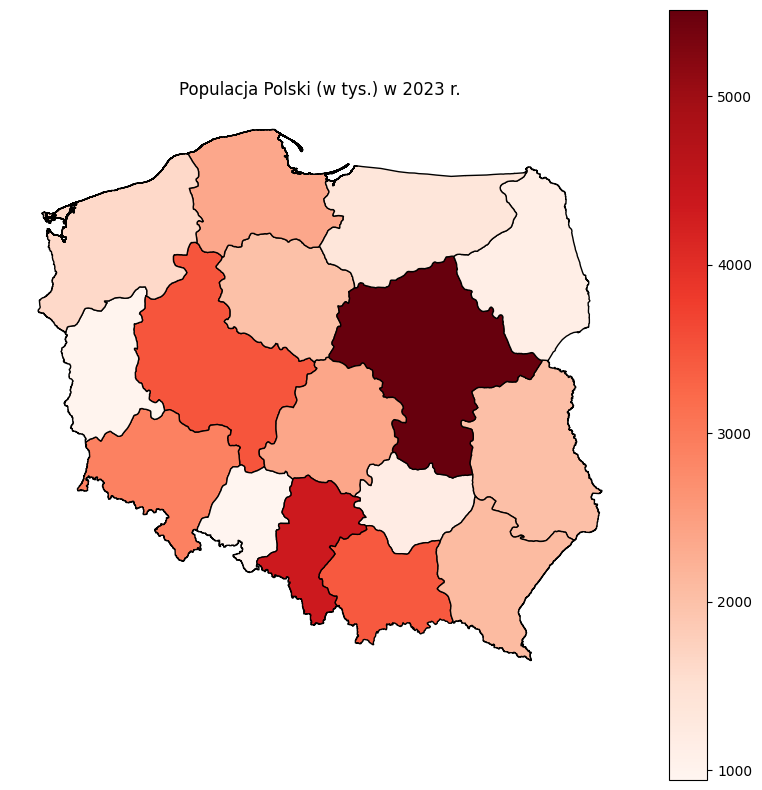

In [5]:
import pandas as pd
url_pl = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/poland.geojson"
df_polska = gpd.read_file(url_pl)

dane_gus = {
    'wojewodztwo': ['Mazowieckie', 'Śląskie', 'Wielkopolskie', 'Małopolskie',
                    'Dolnośląskie', 'Łódzkie', 'Pomorskie', 'Podkarpackie',
                    'Lubelskie', 'Kujawsko-Pomorskie', 'Zachodniopomorskie',
                    'Warmińsko-Mazurskie', 'Świętokrzyskie', 'Podlaskie',
                    'Lubuskie', 'Opolskie'],
    'populacja': [5511, 4346, 3493, 3429, 2888, 2378, 2358, 2085, 2024, 2006, 1638, 1366, 1178, 1143, 984, 942] # w tysiącach
}
df_populacja = pd.DataFrame(dane_gus)
df_mapa_pop = df_polska.merge(df_populacja, left_on='name', right_on='wojewodztwo')
fig, ax = plt.subplots(figsize=(10, 10))
df_mapa_pop.plot(ax=ax, column = 'populacja', cmap = 'Reds', edgecolor = 'black', legend=True)
ax.set_axis_off()
ax.set_title('Populacja Polski (w tys.) w 2023 r.')
plt.show()

---
## Zadanie A (Dla chętnych): Nanoszenie punktów na mapę ze współrzędnych
---

Mapy to nie tylko wielokąty (poligony). Bardzo często otrzymujesz bazę danych klientów lub miast zapisanych po prostu jako dwie kolumny z liczbami: Długość (X - Longitude) i Szerokość (Y - Latitude) geograficzna. Teraz nauczymy się zamieniać surowe cyfry na geometryczne kropki.

---
**Kluczowe funkcje i koncepcje:**
* `gpd.points_from_xy(df['kol_X'], df['kol_Y'])` – funkcja, która z dwóch kolumn z liczbami robi matematyczne obiekty `POINT()`. Należy pamiętać, że najpierw podajemy długość (X/Lon), a potem szerokość (Y/Lat) geograficzną!
* **Rysowanie warstw (Layers):** W Matplotlib na jednym płótnie (`ax`) możesz najpierw narysować mapę (tło), a w kolejnej linijce kodu narysować zbiór punktów. Program ułoży to jak przezroczyste kalki, nakładając kropki na Polskę. Pamiętaj tylko, by w każdym wywołaniu podać `ax=ax`.
* Argument `markersize=...` – używany w funkcji `.plot()` tylko przy rysowaniu punktów. Powiększa widoczną kropkę. Wartość 100-200 daje fajny wizualny efekt na mapie kraju.
---
**Instrukcja krok po kroku:**
1. W kodzie poniżej znajduje się słownik i gotowy `DataFrame` z danymi największych miast w Polsce.
2. Zamień go na `GeoDataFrame` wykonując polecenie:
   `gdf_miasta = gpd.GeoDataFrame(df_miasta, geometry=gpd.points_from_xy(df_miasta['Lon'], df_miasta['Lat']))`.
3. Zainicjuj duże płótno `fig, ax = plt.subplots(figsize=(10, 10))`.
4. Narysuj tło (WARSTWĘ 1). Użyj tabeli z kształtem polski: `df_polska.plot(ax=ax, color='whitesmoke', edgecolor='silver')`. Zobacz, że wybraliśmy subtelne, nie rzucające się w oczy kolory dla samego kraju.
5. Narysuj miasta (WARSTWĘ 2). Użyj tabeli punktowej: `gdf_miasta.plot(...)`. Przekaż do wewnątrz: `ax=ax`, `color='dodgerblue'` (niebieskie kropki), `markersize=150`, `edgecolor='black'`.
6. Pozbądź się brzydkich osi i podziałek wbudowaną w oś funkcją `ax.set_axis_off()`.
7. Dodaj tytuł `"Największe polskie aglomeracje"` i wyświetl całość używając `plt.show()`.
---

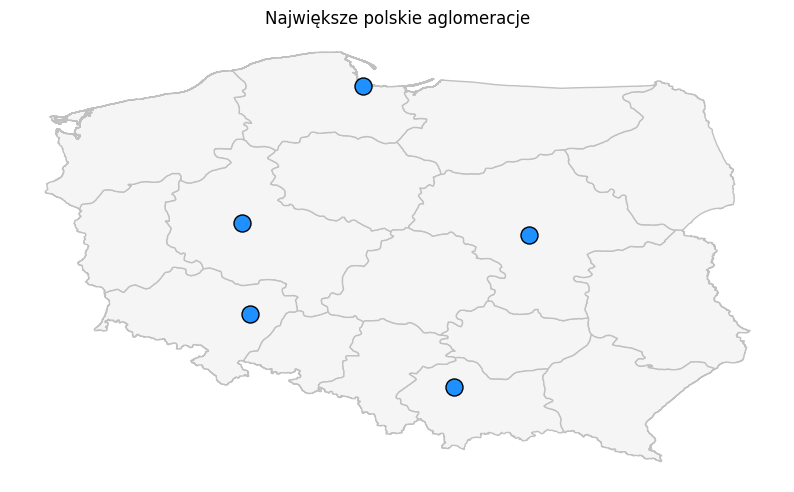

In [13]:
df_miasta = {
    'Miasto': ['Warszawa', 'Kraków', 'Wrocław', 'Poznań', 'Gdańsk'],
    'Lat': [52.2297, 50.0647, 51.1079, 52.4064, 54.3520], # Szerokość - Oś Y
    'Lon': [21.0122, 19.9450, 17.0385, 16.9252, 18.6466]  # Długość - Oś X
}
gdf_miasta = gpd.GeoDataFrame(df_miasta, geometry=gpd.points_from_xy(df_miasta['Lon'], df_miasta['Lat']))
fig, ax = plt.subplots(figsize=(10, 10))
df_polska.plot(ax=ax, color='whitesmoke', edgecolor='silver')
gdf_miasta.plot(ax=ax, color='dodgerblue', markersize=150, edgecolor='black')
ax.set_axis_off()
ax.set_title("Największe polskie aglomeracje")
plt.show()

---
## Zadanie B (Dla chętnych): Analiza przestrzenna – Środek ciężkości (Centroid)
---
Kartogram z Zadania 2 wygląda super, ale nie jest podpisany! Jak programistycznie kazać Pythonowi umieścić napis "Mazowieckie" dokładnie na środku geometrycznym kształtu województwa? Geopandas posiada wbudowane zdolności matematyczne do analizy przestrzennej. Każdy wielokąt ma swój wyliczalny środek zwany **Centroidem**.

Wykorzystamy tę operację do postawienia tekstowych napisów dokładnie tam, gdzie znajduje się środek każdego województwa!

---
**Nowe, niezbędne funkcje:**
* `df.geometry.centroid` – ta metoda wylicza punkt centralny dla każdej figury we wszystkich rzędach w tabeli i zwraca serię obiektów typu POINT().
* `.x` i `.y` – wyciągają poszczególne współrzędne wprost z punktu, co pozwala przekazać je do innych funkcji rysujących.
* `ax.text(X, Y, "Twój Napis")` – standardowa funkcja z pakietu Matplotlib, która umieszcza dany string precyzyjnie we wskazanych współrzędnych na wykresie.
* `zip(lista1, lista2)` – narzędzie języka Python, które pozwala pętli `for` podróżować po dwóch kolumnach z danymi na raz wariant za wariantem (np. biorąc jednocześnie wyliczony środek z kolumny 1 i nazwę z kolumny 2).
---
**Instrukcja krok po kroku:**
1. Do załadowanej już połączonej tabeli (z Zadania 2) o nazwie `df_mapa_pop` dopisz nową kolumnę i nazwij ją `'srodek'`. Wylicz jej wartość uderzając do metody `df_mapa_pop.geometry.centroid`.
2. Odtwórz dokładnie ten sam kartogram co w Zadaniu 2: otwórz płótno 12x12 (`fig, ax = plt.subplots(figsize=(12,12))`), wywołaj `df_mapa_pop.plot(...)`, pokoloruj go używając `cmap='Blues'` (dla odmiany), wyłącz legendę wpisując `legend=False` i nadaj czarne granice.
3. Skonstruuj pętlę iterującą: `for point, nazwa in zip(df_mapa_pop['srodek'], df_mapa_pop['wojewodztwo']):`. Ta pętla za każdym przebiegiem udostępni Ci koordynaty oraz tekst podpisu.
4. Wewnątrz pętli narysuj tekst używając: `ax.text(point.x, point.y, nazwa, ha='center', va='center', fontsize=9, fontweight='bold')`. Parametry `ha` (horizontal alignment) i `va` (vertical alignment) ustawione na `'center'` powodują, że słowo staje na mapie idealnie pośrodku naszego punktu.
5. Zamknij wykres estetycznie wyłączając osie i nadając mu tytuł: np. "Województwa wraz z etykietami na ich Centroidach".
---

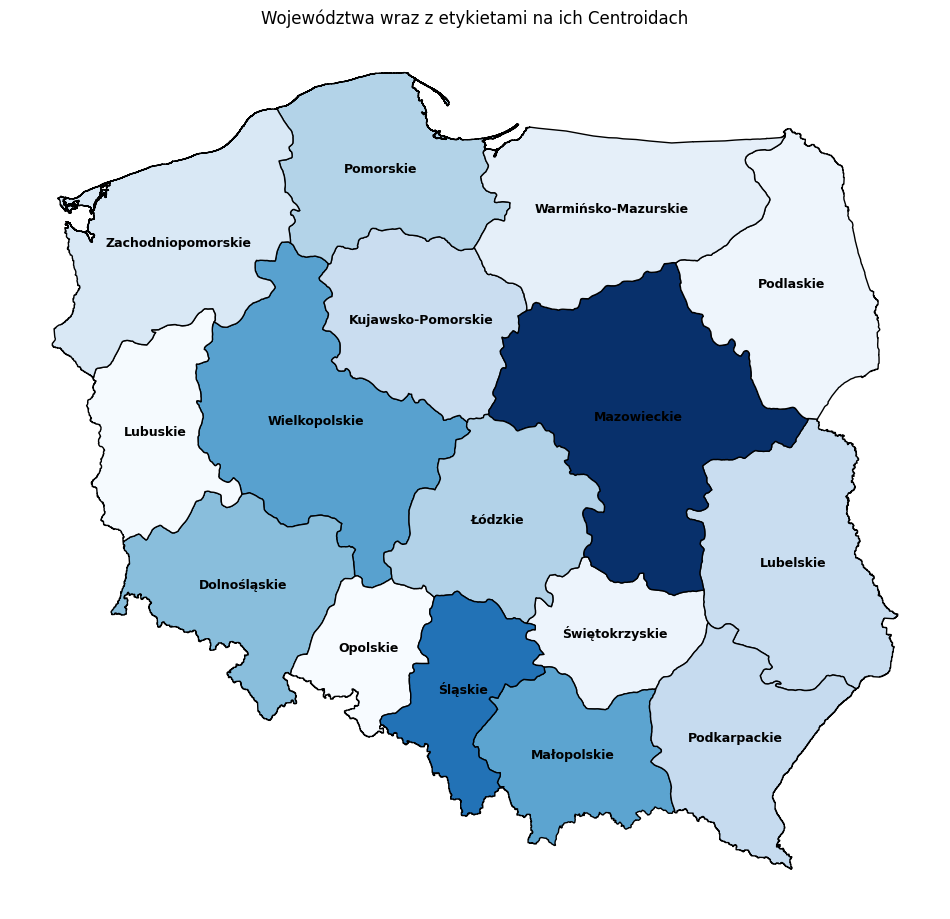

In [16]:
import warnings
warnings.filterwarnings('ignore') # Ukrywa ostrzeżenia środowiska przy wyliczaniu geometrii

df_mapa_pop['srodek'] = df_mapa_pop.geometry.centroid

fig, ax = plt.subplots(figsize=(12, 12))
df_mapa_pop.plot(ax=ax, column='populacja', cmap='Blues', edgecolor='black', legend=False)

for point, nazwa in zip(df_mapa_pop['srodek'], df_mapa_pop['wojewodztwo']):
    ax.text(point.x, point.y, nazwa, ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_axis_off()
ax.set_title('Województwa wraz z etykietami na ich Centroidach')
plt.show()